# MNIST classification with PyTorch
# 2026 Hofstra Teaching and Learning Conference

This notebook:
- Downloads the MNIST Dataset of handwritten digits
- Builds a small CNN
- Trains it with a training loop and validates on the test set
- Shows sample solutions

In [ ]:
# Setup and imports
import os
import random

import numpy as np

# tqdm: show progress bar, no impact on training
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# DataLoader: feeds the model mini-batches of data instead of the entire dataset at once
from torch.utils.data import DataLoader

# torchvision has common datasets (like MNIST) and transforms (like ToTensor/Normalize)
from torchvision import datasets, transforms

import matplotlib.pyplot as plt


# Reproducibility
# Training uses random numbers (random initialization + random shuffling)
# Setting seeds allows for similar results in repeatable runs
seed = 11
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Device selection: CPU vs GPU
# Option to run on NVIDIA GPU with CUDA for more speed and efficiency
# Otherwise it falls back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Hyperparameters (preset training settings)
batch_size = 256          # # of images processed together in one training step
test_batch_size = 1000    # # of images processed together during evaluation
epochs = 10               # # of training loops over entire dataset
learning_rate = 1e-3      # step size for optimizer (how aggressively weights are updated)
# momentum = 0.9          # how much of the previous step direction is kept (unused for Adam)
log_interval = 100        # how often (in batches) to update progress bar info


# Transforms (how raw dataset items get converted before the model sees them)
# MNIST comes as images (28x28 grayscale), model expects numeric tensors

# transforms.ToTensor():
#   - converts a PIL image / numpy array into a PyTorch tensor
#   - scales pixel values from [0, 255] down to [0.0, 1.0]

# transforms.Normalize(mean, std):
#   - standardizes pixels: (x - mean) / std
#   - helps training converge more smoothly

# MNIST's common mean and std (for grayscale) are approximately:
#   mean = 0.1307, std = 0.3081
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
# Datasets and DataLoaders
# datasets.MNIST downloads MNIST if not already present
# train=True gives the training split, train=False gives the test split
data_dir = './data'

train_dataset = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)

# DataLoader breaks the dataset into batches and optionally shuffles
# shuffle=True for training prevents model from seeing digits in a fixed order each epoch
# num_workers: how many extra processes are used to load and transform the data in parallel
# pin_memory=True helps GPU copy faster; does nothing for CPU
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=test_batch_size, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.31MB/s]


In [ ]:
# Define CNN (Convolutional Neural Network)
# CNN works especially well for images
# Uses a "convolution" layer to learn small visual patterns (edges, strokes, etc.)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # One convolution layer
        # nn.Conv2d(in_channels, out_channels, kernel_size, padding)
        # - in_channels=1 because MNIST is grayscale (one channel)
        # - out_channels=16 means the layer learns 16 different filters (feature maps)
        # - kernel_size=3 means each filter is 3x3 pixels
        # - padding=1 keeps output width/height the same (28x28 stays 28x28)
        self.conv = nn.Conv2d(1, 16, kernel_size=3, padding=1)

        # One fully connected layer
        # After conv, the output shape is: (batch, 16, 28, 28)
        # Flatten into a long vector per image: 16*28*28 = 12544

        # nn.Linear(in_features, out_features)
        # out_features=10 because MNIST has 10 classes: digits 0-9
        self.fc = nn.Linear(16*28*28,10)

    def forward(self, x):
        # forward() defines how the input flows through the network

        # x starts as shape: (batch, 1, 28, 28)

        # F.relu(...) applies the ReLU activation:
        #   - ReLU(x) = max(0, x)
        # "Non-linear" step that lets the model learn more complex patterns
        x = F.relu(self.conv(x))  # -> 16×28×28

        # torch.flatten(x, 1) flattens everything except the batch dimension
        # (batch, 16, 28, 28) -> (batch, 16*28*28) -> (batch, 12544)
        x = torch.flatten(x, 1)   # -> 12544 features

        # This produces 10 numbers per image called "logits"
        # Logits are raw scores (not probabilities yet)
        x = self.fc(x)            # -> 10 logits

        return x

# Create model and move it to CPU/GPU device
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=12544, out_features=10, bias=True)
)


In [ ]:
# Loss function + Optimizer
# nn.CrossEntropyLoss is the standard loss for multi-class classification
# It expects:
#   - model outputs: logits of shape (batch, num_classes)
#   - targets: integer class labels of shape (batch,) with values 0-9
criterion = nn.CrossEntropyLoss()

# Adam is a popular optimizer that often works well with little tuning
# It updates model weights based on gradients computed in backward()
# Gradient: how weights will be changed to reduce loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Training and evaluation helper functions
def train_one_epoch(model, device, train_loader, optimizer, criterion, epoch):
    # model.train() turns on "training mode"
    model.train()

    running_loss = 0.0  # sum of losses across the epoch (average at the end)
    correct = 0         # # of correct predictions
    total = 0           # # of images seen

    # tqdm(...) prepares a progress bar over batches
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Train Epoch {epoch}')
    for batch_idx, (data, target) in pbar:
        # data: a batch of images, shape (batch_size, 1, 28, 28)
        # target: the correct digit labels, shape (batch_size,)
        data, target = data.to(device), target.to(device)

        # IMPORTANT: clear old gradients
        # PyTorch accumulates gradients by default, so we zero them each batch
        optimizer.zero_grad()

        # Forward pass: compute logits (raw scores) for each class 0-9
        outputs = model(data)

        # Compute how wrong we are on this batch (loss is a single number)
        loss = criterion(outputs, target)

        # Backward pass: compute gradients of loss with respect to model parameters
        loss.backward()

        # Optimizer step: update weights a little bit in the direction that reduces loss
        optimizer.step()

        # Track average loss/accuracy for the epoch
        running_loss += loss.item() * data.size(0)    # loss.item() is a Python float
        _, predicted = outputs.max(1)                 # predicted class = argmax over 10 logits
        total += target.size(0)                       # add current batch size to total
        correct += predicted.eq(target).sum().item()  # how many correct predictions this epoch

        # Update the progress bar occasionally
        if (batch_idx + 1) % log_interval == 0 or (batch_idx + 1) == len(train_loader):
            pbar.set_postfix({'loss': f'{running_loss/total:.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, device, test_loader, criterion):
    # model.eval() turns on "evaluation mode"
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:                       # loop over test set in batches
            data, target = data.to(device), target.to(device)  # move tensors to CPU or GPU

            outputs = model(data)                              # forward pass
            loss = criterion(outputs, target)                  # compute cross-entropy loss

            test_loss += loss.item() * data.size(0)            # add avg loss * batch size
            _, predicted = outputs.max(1)                      # take index of digit w/ largest logit
            total += target.size(0)                            # add no. of samples in batch
            correct += predicted.eq(target).sum().item()       # add no. of correct predictions

    avg_loss = test_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

In [ ]:
# Training loop
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

best_test_acc = 0.0
# save_dir = './models'
# os.makedirs(save_dir, exist_ok=True)

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, device, train_loader, optimizer, criterion, epoch)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f'Epoch {epoch} summary — Train loss: {train_loss:.4f}, Train acc: {train_acc:.2f}% | Test loss: {test_loss:.4f}, Test acc: {test_acc:.2f}%')

Train Epoch 1:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1 summary — Train loss: 0.2659, Train acc: 92.18% | Test loss: 0.1345, Test acc: 96.24%


Train Epoch 2:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 2 summary — Train loss: 0.1019, Train acc: 97.11% | Test loss: 0.0939, Test acc: 97.25%


Train Epoch 3:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 8 summary — Train loss: 0.0262, Train acc: 99.23% | Test loss: 0.0674, Test acc: 98.02%


Train Epoch 9:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 9 summary — Train loss: 0.0232, Train acc: 99.33% | Test loss: 0.0633, Test acc: 98.05%


Train Epoch 10:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 10 summary — Train loss: 0.0181, Train acc: 99.48% | Test loss: 0.0640, Test acc: 98.07%


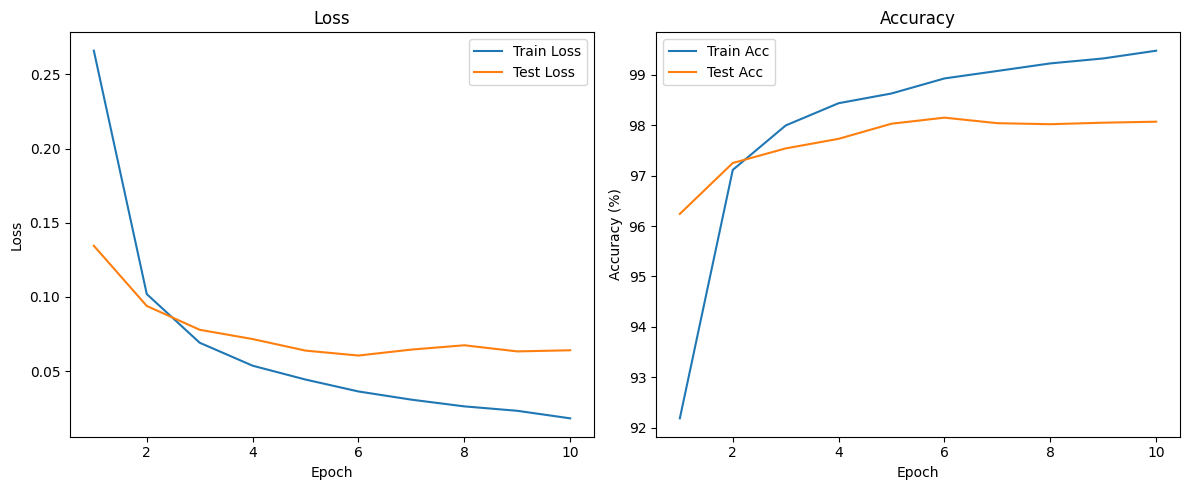

In [ ]:
# Plot loss and accuracy curves
# Visuals for how well the model is learning
# - Loss should generally decrease over epochs
# - Accuracy should generally increase over epochs
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, test_losses,  label='Test Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, label='Train Acc')
plt.plot(epochs_range, test_accuracies,  label='Test Acc')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()


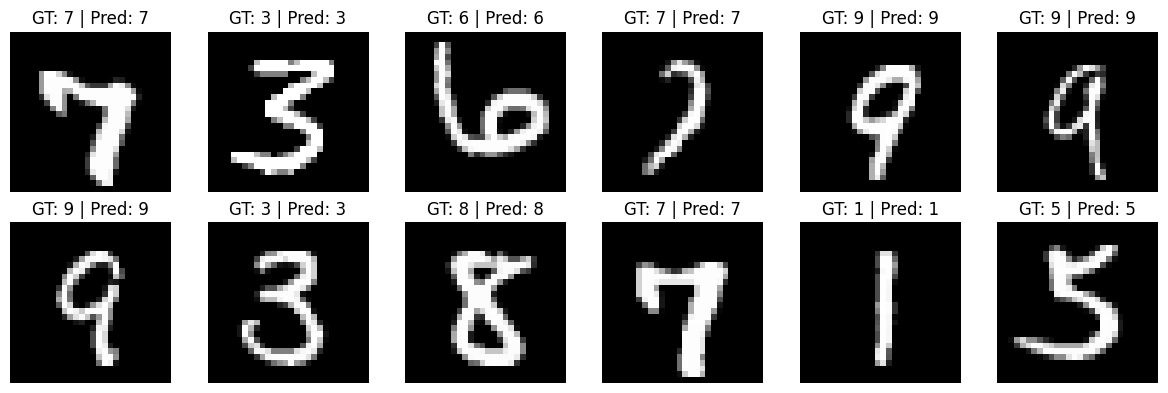

In [ ]:
# Visualize some predictions
# Take a handful of test images, run the model, and print the predicted digit vs the true digit
def show_predictions(model, device, dataset, num_images=12):
    model.eval()

    # Reuse DataLoader as a convenient way to grab a random batch
    loader = DataLoader(test_dataset, batch_size=num_images, shuffle=True)
    data_iter = iter(loader)
    images, labels = next(data_iter)

    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = outputs.max(1) # predicted digit for each image

    # Move tensors back to CPU for plotting, and convert to numpy arrays
    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    preds = preds.cpu().numpy()

    plt.figure(figsize=(12, 4))
    for i in range(num_images):
        plt.subplot(2, num_images // 2, i + 1)

        # images[i] is shape (1, 28, 28); squeeze removes the 1-channel dimension -> (28, 28)
        img = images[i].squeeze()

        # Undo normalization so the image looks normal (reverse of (x - mean)/std):
        # original = normalized * std + mean
        img = img * 0.3081 + 0.1307
        plt.imshow(img, cmap='gray')
        plt.title(f'GT: {labels[i]} | Pred: {preds[i]}')  # GT: Ground Truth
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(model, device, test_dataset, num_images=12)